In [1]:
import os
import numpy as np
import scipy
import matplotlib
from matplotlib import pyplot as plt
from numba import jit
import librosa
import pandas as pd
import IPython.display as ipd

%matplotlib inline


Bad key "text.kerning_factor" on line 4 in
C:\Users\mythk\anaconda3\envs\mir\lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test_patch.mplstyle.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.1.3/matplotlibrc.template
or from the matplotlib source distribution


In [2]:
# Load wav
fn_wav = os.path.join('..', 'Perish Song (Extended).wav')
Fs = 22050
x, Fs = librosa.load(fn_wav, sr=Fs)

In [5]:
def stft_convention_fmp(x, Fs, N, H, pad_mode='constant', center=True, mag=False, gamma=0):
    """Compute the discrete short-time Fourier transform (STFT)

    Notebook: C2/C2_STFT-FreqGridInterpol.ipynb

    Args:
        x (np.ndarray): Signal to be transformed
        Fs (scalar): Sampling rate
        N (int): Window size
        H (int): Hopsize
        pad_mode (str): Padding strategy is used in librosa (Default value = 'constant')
        center (bool): Centric view as used in librosa (Default value = True)
        mag (bool): Computes magnitude STFT if mag==True (Default value = False)
        gamma (float): Constant for logarithmic compression (only applied when mag==True) (Default value = 0)

    Returns:
        X (np.ndarray): Discrete (magnitude) short-time Fourier transform
    """
    X = librosa.stft(x, n_fft=N, hop_length=H, win_length=N,
                     window='hann', pad_mode=pad_mode, center=center)
    if mag:
        X = np.abs(X)**2
        if gamma > 0:
            X = np.log(1 + gamma * X)
    F_coef = librosa.fft_frequencies(sr=Fs, n_fft=N)
    T_coef = librosa.frames_to_time(np.arange(X.shape[1]), sr=Fs, hop_length=H)
    # T_coef = np.arange(X.shape[1]) * H/Fs
    # F_coef = np.arange(N//2+1) * Fs/N
    return X, T_coef, F_coef

In [6]:
# Compute Magnitude STFT
N = 4096
H = 1024
X, T_coef, F_coef = stft_convention_fmp(x, Fs, N, H)
Y = np.abs(X) ** 2

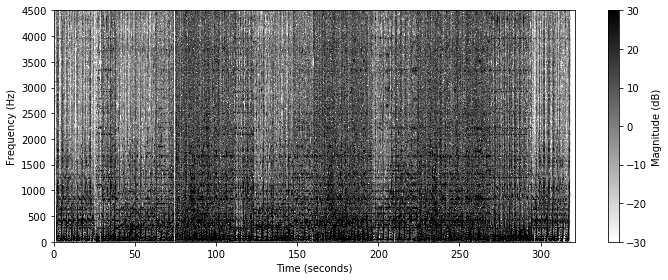

In [7]:
# Plot spectrogram
fig = plt.figure(figsize=(10, 4))
eps = np.finfo(float).eps
plt.imshow(10 * np.log10(eps + Y), origin='lower', aspect='auto', cmap='gray_r', 
           extent=[T_coef[0], T_coef[-1], F_coef[0], F_coef[-1]])
plt.clim([-30, 30])
plt.ylim([0, 4500])
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency (Hz)')
cbar = plt.colorbar()
cbar.set_label('Magnitude (dB)')
plt.tight_layout()

In [8]:
@jit(nopython=True)
def f_pitch(p, pitch_ref=69, freq_ref=440.0):
    """Computes the center frequency/ies of a MIDI pitch

    Notebook: C3/C3S1_SpecLogFreq-Chromagram.ipynb

    Args:
        p (float): MIDI pitch value(s)
        pitch_ref (float): Reference pitch (default: 69)
        freq_ref (float): Frequency of reference pitch (default: 440.0)

    Returns:
        freqs (float): Frequency value(s)
    """
    return 2 ** ((p - pitch_ref) / 12) * freq_ref

@jit(nopython=True)
def pool_pitch(p, Fs, N, pitch_ref=69, freq_ref=440.0):
    """Computes the set of frequency indices that are assigned to a given pitch

    Notebook: C3/C3S1_SpecLogFreq-Chromagram.ipynb

    Args:
        p (float): MIDI pitch value
        Fs (scalar): Sampling rate
        N (int): Window size of Fourier fransform
        pitch_ref (float): Reference pitch (default: 69)
        freq_ref (float): Frequency of reference pitch (default: 440.0)

    Returns:
        k (np.ndarray): Set of frequency indices
    """
    lower = f_pitch(p - 0.5, pitch_ref, freq_ref)
    upper = f_pitch(p + 0.5, pitch_ref, freq_ref)
    k = np.arange(N // 2 + 1)
    k_freq = k * Fs / N  # F_coef(k, Fs, N)
    mask = np.logical_and(lower <= k_freq, k_freq < upper)
    return k[mask]

@jit(nopython=True)
def compute_spec_log_freq(Y, Fs, N):
    """Computes a log-frequency spectrogram

    Notebook: C3/C3S1_SpecLogFreq-Chromagram.ipynb

    Args:
        Y (np.ndarray): Magnitude or power spectrogram
        Fs (scalar): Sampling rate
        N (int): Window size of Fourier fransform

    Returns:
        Y_LF (np.ndarray): Log-frequency spectrogram
        F_coef_pitch (np.ndarray): Pitch values
    """
    Y_LF = np.zeros((128, Y.shape[1]))
    for p in range(128):
        k = pool_pitch(p, Fs, N)
        Y_LF[p, :] = Y[k, :].sum(axis=0)
    F_coef_pitch = np.arange(128)
    return Y_LF, F_coef_pitch

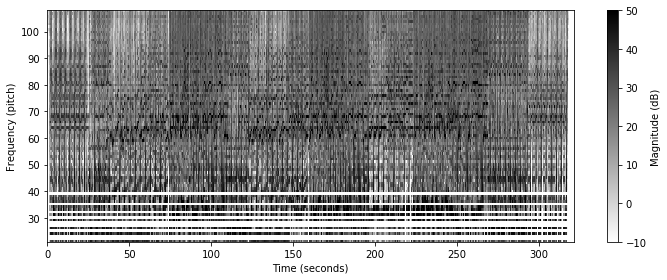

In [9]:
Y_LF, F_coef_pitch = compute_spec_log_freq(Y, Fs, N)        

fig = plt.figure(figsize=(10, 4))
plt.imshow(10 * np.log10(eps + Y_LF), origin='lower', aspect='auto', cmap='gray_r', 
           extent=[T_coef[0], T_coef[-1], 0, 127])
plt.clim([-10, 50])
plt.ylim([21, 108])
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency (pitch)')
cbar = plt.colorbar()
cbar.set_label('Magnitude (dB)')

plt.tight_layout()

In [10]:
@jit(nopython=True)
def compute_chromagram(Y_LF):
    """Computes a chromagram

    Notebook: C3/C3S1_SpecLogFreq-Chromagram.ipynb

    Args:
        Y_LF (np.ndarray): Log-frequency spectrogram

    Returns:
        C (np.ndarray): Chromagram
    """
    C = np.zeros((12, Y_LF.shape[1]))
    p = np.arange(128)
    for c in range(12):
        mask = (p % 12) == c
        C[c, :] = Y_LF[mask, :].sum(axis=0)
    return C

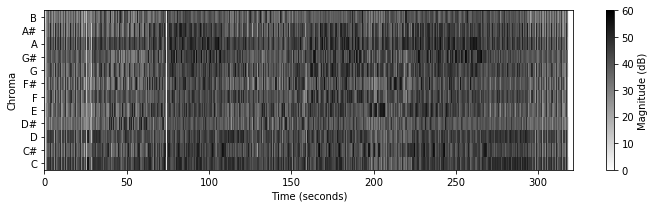

In [11]:
C = compute_chromagram(Y_LF)

fig = plt.figure(figsize=(10, 3))
chroma_label = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
plt.imshow(10 * np.log10(eps + C), origin='lower', aspect='auto', cmap='gray_r', 
           extent=[T_coef[0], T_coef[-1], 0, 12])
plt.clim([0, 60])
plt.xlabel('Time (seconds)')
plt.ylabel('Chroma')
cbar = plt.colorbar()
cbar.set_label('Magnitude (dB)')
plt.yticks(np.arange(12) + 0.5, chroma_label)
plt.tight_layout()